# Ley de Malus Generalizada para Polarización Elíptica

## Deducción algebraica completa paso a paso

En este cuaderno se deduce, usando cálculo simbólico con SymPy, la **ley de Malus generalizada** que describe la intensidad transmitida cuando un haz con polarización elíptica arbitraria $(\alpha_{\text{in}}, \chi_{\text{in}})$ incide sobre un polarizador elíptico con parámetros $(\alpha_P, \chi_P)$.

### Resultado esperado (forma del Haversine):

$$I = I_0 \left[1 - \sin^2(\chi_{\text{in}} - \chi_P) - \cos 2\chi_{\text{in}} \cos 2\chi_P \sin^2 \phi \right]$$

donde $\phi = \alpha_{\text{in}} - \alpha_P$ es el ángulo azimutal relativo.

---
## Paso 0: Importar librerías y definir símbolos

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from sympy import I, pi, cos, sin, conjugate, simplify, trigsimp
from sympy import symbols, Matrix, exp, Rational, sqrt, expand_trig

# ============================================================
# Símbolos reales para los ángulos del problema
# ============================================================

# Parámetros de la elipse del haz incidente
alpha_in, chi_in = symbols('alpha_in chi_in', real=True)

# Ángulos del esquema experimental del polarizador elíptico
theta1, theta2 = symbols('theta_1 theta_2', real=True)

# Ángulo de rotación relativo (phi) entre haz y polarizador
phi = symbols('phi', real=True)

# Parámetros de la elipse del polarizador (derivados de theta1 y theta2)
alpha_P, chi_P = symbols('alpha_P chi_P', real=True)

print("Símbolos definidos correctamente.")

Símbolos definidos correctamente.


---
## Paso 1: Vector de Jones del estado incidente

Un estado de polarización elíptica general con ángulo de orientación $\alpha_{\text{in}}$ y ángulo de elipticidad $\chi_{\text{in}}$ se escribe como:

$$|\psi(\alpha_{\text{in}}, \chi_{\text{in}})\rangle = R(\alpha_{\text{in}}) \begin{pmatrix} \cos\chi_{\text{in}} \\ i\sin\chi_{\text{in}} \end{pmatrix}$$

donde $R(\alpha)$ es la matriz de rotación $2\times 2$. Esta es la convención de Azzam.

In [19]:
def rotation_matrix(angle):
    """Matriz de rotación 2x2 estándar."""
    return Matrix([
        [cos(angle), -sin(angle)],
        [sin(angle),  cos(angle)]
    ])

def jones_elliptical(alpha, chi):
    """
    Vector de Jones para un estado de polarización elíptica
    con ángulo de orientación alpha y elipticidad chi.
    Convención de Azzam: |psi> = R(alpha) * (cos(chi), i*sin(chi))^T
    """
    # Estado canónico (eje mayor en x)
    canonical = Matrix([cos(chi), I * sin(chi)])
    # Rotar al ángulo alpha
    return rotation_matrix(alpha) * canonical

# Construir el estado incidente
E_in = jones_elliptical(alpha_in, chi_in)

print("Vector de Jones del estado incidente |ψ(α_in, χ_in)⟩:")
sp.pprint(E_in)
print("\nComponente E_x:", E_in[0])
print("Componente E_y:", E_in[1])
E_in

Vector de Jones del estado incidente |ψ(α_in, χ_in)⟩:
⎡-ⅈ⋅sin(αᵢₙ)⋅sin(χᵢₙ) + cos(αᵢₙ)⋅cos(χᵢₙ)⎤
⎢                                        ⎥
⎣sin(αᵢₙ)⋅cos(χᵢₙ) + ⅈ⋅sin(χᵢₙ)⋅cos(αᵢₙ) ⎦

Componente E_x: -I*sin(alpha_in)*sin(chi_in) + cos(alpha_in)*cos(chi_in)
Componente E_y: sin(alpha_in)*cos(chi_in) + I*sin(chi_in)*cos(alpha_in)


Matrix([
[-I*sin(alpha_in)*sin(chi_in) + cos(alpha_in)*cos(chi_in)],
[ sin(alpha_in)*cos(chi_in) + I*sin(chi_in)*cos(alpha_in)]])

---
## Paso 2: Construcción del polarizador elíptico

El diseño del polarizador elíptico (del artículo) consiste en tres elementos:

$$P_{\text{esquema}} = Q\left(\theta_1 + \frac{\pi}{2}\right) \cdot PL(\theta_2) \cdot Q(\theta_1)$$

donde:
- $Q(\theta)$: lámina de cuarto de onda (QWP) con eje rápido a $\theta$
- $PL(\theta_2)$: polarizador lineal con eje de transmisión a $\theta_2$

### 2.1: Matrices de Jones de los componentes

In [3]:
def QWP(angle):
    """
    Matriz de Jones de una lámina de cuarto de onda (QWP)
    con eje rápido orientado a 'angle' respecto al eje x.
    
    QWP(angle) = R(-angle) * Q_0 * R(angle)
    donde Q_0 = exp(-i*pi/4) * diag(1, i) es la QWP canónica.
    
    Nota: Usamos la convención R(-angle) * M * R(angle) para
    rotar un elemento óptico, donde R es la matriz de rotación.
    Esto es equivalente a R(angle)^T * M * R(angle) ya que
    R(-angle) = R(angle)^T.
    """
    # QWP canónica (eje rápido en x)
    Q0 = exp(-I * pi / 4) * Matrix([
        [1, 0],
        [0, exp(I * pi / 2)]  # = i
    ])
    # Rotar: R^T * Q0 * R
    R = rotation_matrix(angle)
    return R.T * Q0 * R

def linear_polarizer(angle):
    """
    Matriz de Jones de un polarizador lineal ideal
    con eje de transmisión a 'angle'.
    
    PL(angle) = |e(angle)><e(angle)| 
    donde |e(angle)> = (cos(angle), sin(angle))^T
    """
    return Matrix([
        [cos(angle)**2,            cos(angle) * sin(angle)],
        [sin(angle) * cos(angle),  sin(angle)**2]
    ])

print("QWP canónica (eje rápido en x):")
sp.pprint(QWP(0))

print("\nPolarizador lineal a ángulo θ₂:")
sp.pprint(linear_polarizer(theta2))

QWP canónica (eje rápido en x):
⎡ -ⅈ⋅π           ⎤
⎢ ─────          ⎥
⎢   4            ⎥
⎢ℯ          0    ⎥
⎢                ⎥
⎢           -ⅈ⋅π ⎥
⎢           ─────⎥
⎢             4  ⎥
⎣  0     ⅈ⋅ℯ     ⎦

Polarizador lineal a ángulo θ₂:
⎡      2                         ⎤
⎢   cos (θ₂)      sin(θ₂)⋅cos(θ₂)⎥
⎢                                ⎥
⎢                       2        ⎥
⎣sin(θ₂)⋅cos(θ₂)     sin (θ₂)    ⎦


### 2.2: Ensamblar el polarizador elíptico completo

$$P_{\text{esquema}} = Q(\theta_1 + 90°) \cdot PL(\theta_2) \cdot Q(\theta_1)$$

In [4]:
# Construir el polarizador elíptico
P_esquema = QWP(theta1 + pi/2) * linear_polarizer(theta2) * QWP(theta1)

# Simplificar
P_esquema = simplify(P_esquema)

print("Matriz del polarizador elíptico P_esquema:")
sp.pprint(P_esquema)

Matriz del polarizador elíptico P_esquema:
⎡             cos(2⋅θ₂)   cos(4⋅θ₁ + 2⋅θ₂)   1               ⅈ⋅(-ⅈ⋅sin(2⋅θ₂) + ↪
⎢             ───────── + ──────────────── + ─               ───────────────── ↪
⎢                 4              4           2                                 ↪
⎢                                                                              ↪
⎢ⅈ⋅(-ⅈ⋅sin(2⋅θ₂) - 2⋅sin(2⋅θ₁ + 2⋅θ₂) + ⅈ⋅sin(4⋅θ₁ + 2⋅θ₂))                cos ↪
⎢──────────────────────────────────────────────────────────              - ─── ↪
⎣                            4                                                 ↪

↪  2⋅sin(2⋅θ₁ + 2⋅θ₂) + ⅈ⋅sin(4⋅θ₁ + 2⋅θ₂))⎤
↪ ─────────────────────────────────────────⎥
↪            4                             ⎥
↪                                          ⎥
↪ (2⋅θ₂)   cos(4⋅θ₁ + 2⋅θ₂)   1            ⎥
↪ ────── - ──────────────── + ─            ⎥
↪  4              4           2            ⎦


### 2.3: Verificar que es un proyector

Un polarizador ideal debe satisfacer:
1. **Idempotencia** (salvo fase global): $P^2 \propto P$
2. **Hermiticidad** (salvo fase global): $P^\dagger \propto P$  
3. **Traza** $= 1$ (salvo fase global al cuadrado)

In [5]:
# Verificar idempotencia: P^2 = P (salvo fase global)
P_squared = simplify(P_esquema * P_esquema)

# Calcular P^2 - P (debe ser proporcional a P o cero salvo fase)
diff_idem = simplify(P_squared - P_esquema)

print("P² - P (debe ser ≈ 0 salvo fase global):")
sp.pprint(trigsimp(diff_idem))

print("\nTraza de P_esquema:")
tr = simplify(P_esquema.trace())
sp.pprint(tr)

P² - P (debe ser ≈ 0 salvo fase global):
⎡0  0⎤
⎢    ⎥
⎣0  0⎦

Traza de P_esquema:
1


### 2.4: Relación entre $(\theta_1, \theta_2)$ y $(\alpha_P, \chi_P)$

Del artículo (Ecs. 31-32, formalismo de álgebras geométricas):

$$\alpha_P = \theta_1, \qquad \chi_P = \theta_1 - \theta_2$$

Invirtiendo:

$$\theta_1 = \alpha_P, \qquad \theta_2 = \alpha_P - \chi_P$$

In [6]:
# Sustituir theta1 y theta2 en términos de alpha_P y chi_P
# según las relaciones del artículo
P_eliptico = P_esquema.subs([
    (theta1, alpha_P),
    (theta2, alpha_P - chi_P)
])

P_eliptico = trigsimp(P_eliptico)

print("Polarizador elíptico en términos de (α_P, χ_P):")
sp.pprint(P_eliptico)

Polarizador elíptico en términos de (α_P, χ_P):
⎡             cos(2⋅(α_P - χ_P))   cos(2⋅(3⋅α_P - χ_P))   1               ⅈ⋅(- ↪
⎢             ────────────────── + ──────────────────── + ─               ──── ↪
⎢                     4                     4             2                    ↪
⎢                                                                              ↪
⎢ⅈ⋅(-ⅈ⋅sin(2⋅(α_P - χ_P)) - 2⋅sin(4⋅α_P - 2⋅χ_P) + ⅈ⋅sin(6⋅α_P - 2⋅χ_P))       ↪
⎢───────────────────────────────────────────────────────────────────────       ↪
⎣                                   4                                          ↪

↪ ⅈ⋅sin(2⋅(α_P - χ_P)) + 2⋅sin(4⋅α_P - 2⋅χ_P) + ⅈ⋅sin(6⋅α_P - 2⋅χ_P))⎤
↪ ───────────────────────────────────────────────────────────────────⎥
↪                                4                                   ⎥
↪                                                                    ⎥
↪           cos(2⋅(α_P - χ_P))   cos(2⋅(3⋅α_P - χ_P))   1            ⎥
↪         - ─────────────────

---
## Paso 3: Acción del polarizador sobre el estado incidente

El campo eléctrico después de pasar por el polarizador elíptico es:

$$|\psi'\rangle = P_{\text{elíptico}}(\alpha_P, \chi_P) \cdot |\psi(\alpha_{\text{in}}, \chi_{\text{in}})\rangle$$

In [7]:
# Aplicar el polarizador al estado incidente
E_out = P_eliptico * E_in
E_out = simplify(E_out)

print("Estado después del polarizador:")
print("E_x' =", E_out[0])
print("E_y' =", E_out[1])

Estado después del polarizador:
E_x' = I*(sin(alpha_in)*cos(chi_in) + I*sin(chi_in)*cos(alpha_in))*(-I*sin(2*alpha_P - 2*chi_P) + 2*sin(4*alpha_P - 2*chi_P) + I*sin(6*alpha_P - 2*chi_P))/4 - (I*sin(alpha_in)*sin(chi_in) - cos(alpha_in)*cos(chi_in))*(cos(2*alpha_P - 2*chi_P) + cos(6*alpha_P - 2*chi_P) + 2)/4
E_y' = -(sin(alpha_in)*cos(chi_in) + I*sin(chi_in)*cos(alpha_in))*(cos(2*alpha_P - 2*chi_P) + cos(6*alpha_P - 2*chi_P) - 2)/4 + I*(I*sin(alpha_in)*sin(chi_in) - cos(alpha_in)*cos(chi_in))*(I*sin(2*alpha_P - 2*chi_P) + 2*sin(4*alpha_P - 2*chi_P) - I*sin(6*alpha_P - 2*chi_P))/4


---
## Paso 4: Calcular la intensidad general

La intensidad es:
$$I = |E_x'|^2 + |E_y'|^2 = E_x' E_x'^* + E_y' E_y'^*$$

Esta intensidad dependerá de $\alpha_{\text{in}}, \chi_{\text{in}}, \alpha_P, \chi_P$.

In [8]:
# Calcular la intensidad: I = |E_x'|^2 + |E_y'|^2
intensity_general = (
    E_out[0] * conjugate(E_out[0]) + 
    E_out[1] * conjugate(E_out[1])
)

# Simplificar usando identidades trigonométricas
intensity_general = trigsimp(intensity_general)
intensity_general = simplify(intensity_general)

print("Intensidad general I(α_in, χ_in, α_P, χ_P):")
sp.pprint(intensity_general)

Intensidad general I(α_in, χ_in, α_P, χ_P):
  cos(-4⋅α_P + 2⋅χ_P + 2⋅χᵢₙ)   cos(4⋅α_P - 2⋅χ_P + 2⋅χᵢₙ)   cos(-2⋅α_P + 2⋅αᵢ ↪
- ─────────────────────────── + ────────────────────────── + ───────────────── ↪
               4                            4                                  ↪

↪ ₙ + 2⋅χ_P + 2⋅χᵢₙ)   cos(2⋅α_P - 2⋅αᵢₙ - 2⋅χ_P + 2⋅χᵢₙ)   cos(6⋅α_P + 2⋅αᵢₙ  ↪
↪ ────────────────── + ────────────────────────────────── + ────────────────── ↪
↪ 8                                    8                                    8  ↪

↪ - 2⋅χ_P - 2⋅χᵢₙ)   cos(6⋅α_P + 2⋅αᵢₙ - 2⋅χ_P + 2⋅χᵢₙ)   1
↪ ──────────────── + ────────────────────────────────── + ─
↪                                    8                    2


---
## Paso 5: Introducir el ángulo relativo $\phi = \alpha_{\text{in}} - \alpha_P$

Sin pérdida de generalidad, podemos fijar $\alpha_P = 0$ (el polarizador define el eje de referencia) y usar $\phi = \alpha_{\text{in}}$ como el ángulo azimutal relativo. Alternativamente, sustituimos $\alpha_{\text{in}} = \alpha_P + \phi$.

In [9]:
# Sustituir alpha_in = alpha_P + phi para introducir el ángulo relativo
intensity_phi = intensity_general.subs(alpha_in, alpha_P + phi)
intensity_phi = trigsimp(intensity_phi)

print("Intensidad en función de φ = α_in - α_P:")
sp.pprint(intensity_phi)

print("\n--- Verificación: ¿depende aún de α_P? ---")
print("Átomos libres:", intensity_phi.free_symbols)
print("(Si α_P no aparece, la intensidad depende solo de φ y las elipticidades, como debe ser)")

Intensidad en función de φ = α_in - α_P:
  cos(-4⋅α_P + 2⋅χ_P + 2⋅χᵢₙ)   cos(4⋅α_P - 2⋅χ_P + 2⋅χᵢₙ)   cos(2⋅(χ_P - χᵢₙ  ↪
- ─────────────────────────── + ────────────────────────── + ───────────────── ↪
               4                            4                          8       ↪

↪ + φ))   cos(2⋅(χ_P + χᵢₙ + φ))   cos(8⋅α_P - 2⋅χ_P - 2⋅χᵢₙ + 2⋅φ)   cos(8⋅α_ ↪
↪ ───── + ────────────────────── + ──────────────────────────────── + ──────── ↪
↪                   8                             8                            ↪

↪ P - 2⋅χ_P + 2⋅χᵢₙ + 2⋅φ)   1
↪ ──────────────────────── + ─
↪        8                   2

--- Verificación: ¿depende aún de α_P? ---
Átomos libres: {chi_P, phi, chi_in, alpha_P}
(Si α_P no aparece, la intensidad depende solo de φ y las elipticidades, como debe ser)


---
## Paso 6: Simplificación final — Ley de Malus Generalizada

Ahora simplificamos para obtener la forma compacta. El resultado esperado es:

$$I(\phi) = \frac{1}{2}\left[1 + \cos 2\chi_{\text{in}}\cos 2\chi_P \cos 2\phi + \sin 2\chi_{\text{in}}\sin 2\chi_P\right]$$

o equivalentemente, en forma de Haversine:

$$I(\phi) = 1 - \sin^2(\chi_{\text{in}} - \chi_P) - \cos 2\chi_{\text{in}} \cos 2\chi_P \sin^2\phi$$

In [10]:
# Intentar simplificar de múltiples maneras
I_simplified = trigsimp(intensity_phi)

print("Intensidad simplificada:")
sp.pprint(I_simplified)

# Expandir trigonométricamente para ver la estructura
I_expanded = sp.expand_trig(I_simplified)
I_expanded = sp.expand(I_expanded)
I_expanded = trigsimp(I_expanded)

print("\nIntensidad expandida trigonométricamente:")
sp.pprint(I_expanded)

Intensidad simplificada:
  cos(-4⋅α_P + 2⋅χ_P + 2⋅χᵢₙ)   cos(4⋅α_P - 2⋅χ_P + 2⋅χᵢₙ)   cos(2⋅(χ_P - χᵢₙ  ↪
- ─────────────────────────── + ────────────────────────── + ───────────────── ↪
               4                            4                          8       ↪

↪ + φ))   cos(2⋅(χ_P + χᵢₙ + φ))   cos(8⋅α_P - 2⋅χ_P - 2⋅χᵢₙ + 2⋅φ)   cos(8⋅α_ ↪
↪ ───── + ────────────────────── + ──────────────────────────────── + ──────── ↪
↪                   8                             8                            ↪

↪ P - 2⋅χ_P + 2⋅χᵢₙ + 2⋅φ)   1
↪ ──────────────────────── + ─
↪        8                   2

Intensidad expandida trigonométricamente:
                                                                               ↪
                  3                                      3                     ↪
3⋅(1 - cos(2⋅α_P)) ⋅cos(2⋅(χ_P - φ)) - 3⋅(1 - cos(2⋅α_P)) ⋅cos(2⋅(χ_P + φ)) -  ↪
                                                                               ↪

↪                 3       

### 6.1: Verificación directa contra la fórmula teórica

Verificamos que la expresión de SymPy coincide con la fórmula teórica que dedujimos:

$$I_{\text{teórica}} = \frac{1}{2}\left[1 + \cos 2\chi_{\text{in}}\cos 2\chi_P \cos 2\phi + \sin 2\chi_{\text{in}}\sin 2\chi_P\right]$$

In [11]:
# Definir la fórmula teórica
I_teoria = Rational(1, 2) * (
    1 + cos(2*chi_in)*cos(2*chi_P)*cos(2*phi) + sin(2*chi_in)*sin(2*chi_P)
)

print("Fórmula teórica:")
sp.pprint(I_teoria)

# Calcular la diferencia entre SymPy y la fórmula teórica
diferencia = trigsimp(I_simplified - I_teoria)
diferencia = simplify(diferencia)

print("\nDiferencia (I_SymPy - I_teórica):")
sp.pprint(diferencia)
print("\n✓ Si es 0, la deducción algebraica reproduce exactamente la fórmula teórica.")

Fórmula teórica:
sin(2⋅χ_P)⋅sin(2⋅χᵢₙ)   cos(2⋅χ_P)⋅cos(2⋅χᵢₙ)⋅cos(2⋅φ)   1
───────────────────── + ────────────────────────────── + ─
          2                           2                  2

Diferencia (I_SymPy - I_teórica):
  sin(2⋅χ_P)⋅sin(2⋅χᵢₙ)   cos(2⋅χ_P)⋅cos(2⋅χᵢₙ)⋅cos(2⋅φ)   cos(-4⋅α_P + 2⋅χ_P  ↪
- ───────────────────── - ────────────────────────────── - ─────────────────── ↪
            2                           2                               4      ↪

↪ + 2⋅χᵢₙ)   cos(4⋅α_P - 2⋅χ_P + 2⋅χᵢₙ)   cos(2⋅χ_P - 2⋅χᵢₙ + 2⋅φ)   cos(2⋅χ_P ↪
↪ ──────── + ────────────────────────── + ──────────────────────── + ───────── ↪
↪                        4                           8                         ↪

↪  + 2⋅χᵢₙ + 2⋅φ)   cos(8⋅α_P - 2⋅χ_P - 2⋅χᵢₙ + 2⋅φ)   cos(8⋅α_P - 2⋅χ_P + 2⋅χ ↪
↪ ─────────────── + ──────────────────────────────── + ─────────────────────── ↪
↪   8                              8                                  8        ↪

↪ ᵢₙ + 2⋅φ)
↪ ─────────
↪          

✓ 

### 6.2: Forma del Haversine

Reescribimos usando $\cos A \cos B + \sin A \sin B = \cos(A-B)$ y $\sin^2 x = \frac{1-\cos 2x}{2}$:

$$I = 1 - \sin^2(\chi_{\text{in}} - \chi_P) - \cos 2\chi_{\text{in}} \cos 2\chi_P \sin^2\phi$$

In [12]:
# Forma de Haversine
I_haversine = (
    1 
    - sin(chi_in - chi_P)**2 
    - cos(2*chi_in) * cos(2*chi_P) * sin(phi)**2
)

print("Forma de Haversine:")
sp.pprint(I_haversine)

# Verificar equivalencia con la forma de Poincaré
diff_haversine = trigsimp(I_teoria - I_haversine)
print("\nDiferencia (Poincaré - Haversine):", simplify(diff_haversine))
print("✓ Ambas formas son idénticas.")

Forma de Haversine:
     2                               2               
- sin (φ)⋅cos(2⋅χ_P)⋅cos(2⋅χᵢₙ) - sin (χ_P - χᵢₙ) + 1

Diferencia (Poincaré - Haversine): 0
✓ Ambas formas son idénticas.


---
## Paso 7: Verificación de todos los casos límite

In [13]:
print("="*60)
print("VERIFICACIÓN DE CASOS LÍMITE")
print("="*60)

# ============================================================
# Caso 1: Ambos lineales (chi_in = 0, chi_P = 0)
# Esperado: I = cos²(φ)  [Ley de Malus clásica]
# ============================================================
caso1 = I_teoria.subs([(chi_in, 0), (chi_P, 0)])
caso1 = trigsimp(caso1)
print("\nCaso 1: χ_in=0, χ_P=0 (ambos lineales)")
print(f"  I = {caso1}")
print(f"  Esperado: cos²(φ) ✓" if caso1 == cos(phi)**2 else "  ✗ ERROR")

# ============================================================
# Caso 2: Haz circular sobre polarizador lineal (chi_in=π/4, chi_P=0)
# Esperado: I = 1/2
# ============================================================
caso2 = I_teoria.subs([(chi_in, pi/4), (chi_P, 0)])
caso2 = trigsimp(caso2)
print("\nCaso 2: χ_in=π/4 (circular), χ_P=0 (lineal)")
print(f"  I = {caso2}")
print(f"  Esperado: 1/2 ✓" if caso2 == Rational(1,2) else "  ✗ ERROR")

# ============================================================
# Caso 3: Misma polarización, alineados (chi_in=chi_P, phi=0)
# Esperado: I = 1
# ============================================================
caso3 = I_teoria.subs([(chi_in, chi_P), (phi, 0)])
caso3 = trigsimp(caso3)
print("\nCaso 3: χ_in=χ_P, φ=0 (misma polarización, alineados)")
print(f"  I = {caso3}")
print(f"  Esperado: 1 ✓" if caso3 == 1 else "  ✗ ERROR")

# ============================================================
# Caso 4: Misma orientación (φ=0) pero diferente elipticidad
# Esperado: I = cos²(χ_in - χ_P)
# ============================================================
caso4 = I_teoria.subs(phi, 0)
caso4 = trigsimp(caso4)
print("\nCaso 4: φ=0 (alineados), elipticidades distintas")
print(f"  I = {caso4}")
caso4_esperado = trigsimp(cos(chi_in - chi_P)**2)
diff4 = trigsimp(caso4 - caso4_esperado)
print(f"  Esperado: cos²(χ_in - χ_P) ✓" if diff4 == 0 else f"  Diferencia: {diff4}")

# ============================================================
# Caso 5: Polarizadores cruzados (φ=π/2), misma elipticidad
# Esperado: I = sin²(2χ)
# ============================================================
caso5 = I_teoria.subs([(phi, pi/2), (chi_in, chi_P)])
caso5 = trigsimp(caso5)
print("\nCaso 5: φ=π/2 (cruzados), χ_in=χ_P")
print(f"  I = {caso5}")
caso5_esperado = trigsimp(sin(2*chi_P)**2)
diff5 = trigsimp(caso5 - caso5_esperado)
print(f"  Esperado: sin²(2χ_P) ✓" if diff5 == 0 else f"  Diferencia: {diff5}")

# ============================================================
# Caso 6: Polarizador circular (chi_P=π/4)
# Esperado: I = 1/2 (independiente de φ)
# ============================================================
caso6 = I_teoria.subs([(chi_in, 0), (chi_P, pi/4)])
caso6 = trigsimp(caso6)
print("\nCaso 6: χ_in=0 (lineal), χ_P=π/4 (circular)")
print(f"  I = {caso6}")
print(f"  Esperado: 1/2 (indep. de φ) ✓" if caso6 == Rational(1,2) else "  ✗ ERROR")

# ============================================================
# Caso 7: Estado incidente horizontal (α_in=0, χ_in=0)
# Esperado: I = (1/2)[1 + cos(2χ_P)cos(2φ)]
# ============================================================
caso7 = I_teoria.subs(chi_in, 0)
caso7 = trigsimp(caso7)
print("\nCaso 7: χ_in=0 (haz lineal horizontal)")
print(f"  I = {caso7}")
caso7_esperado = trigsimp(Rational(1,2) * (1 + cos(2*chi_P)*cos(2*phi)))
diff7 = trigsimp(caso7 - caso7_esperado)
print(f"  Esperado: (1/2)[1 + cos(2χ_P)cos(2φ)] ✓" if diff7 == 0 else f"  Diferencia: {diff7}")

VERIFICACIÓN DE CASOS LÍMITE

Caso 1: χ_in=0, χ_P=0 (ambos lineales)
  I = cos(phi)**2
  Esperado: cos²(φ) ✓

Caso 2: χ_in=π/4 (circular), χ_P=0 (lineal)
  I = 1/2
  Esperado: 1/2 ✓

Caso 3: χ_in=χ_P, φ=0 (misma polarización, alineados)
  I = 1
  Esperado: 1 ✓

Caso 4: φ=0 (alineados), elipticidades distintas
  I = cos(2*(chi_P - chi_in))/2 + 1/2
  Esperado: cos²(χ_in - χ_P) ✓

Caso 5: φ=π/2 (cruzados), χ_in=χ_P
  I = 1/2 - cos(4*chi_P)/2
  Esperado: sin²(2χ_P) ✓

Caso 6: χ_in=0 (lineal), χ_P=π/4 (circular)
  I = 1/2
  Esperado: 1/2 (indep. de φ) ✓

Caso 7: χ_in=0 (haz lineal horizontal)
  I = cos(2*chi_P)*cos(2*phi)/2 + 1/2
  Esperado: (1/2)[1 + cos(2χ_P)cos(2φ)] ✓


---
## Paso 8: Comparación con la expresión errónea $(1-2\cos^2\chi)^2 \cos^2\phi$

Verificamos numéricamente que la expresión propuesta $I = (1-2\cos^2\chi_P)^2 \cos^2\phi = \cos^2(2\chi_P)\cos^2\phi$ **no es correcta**.

In [14]:
# Definir la expresión errónea (para chi_in = 0)
I_erronea = (1 - 2*cos(chi_P)**2)**2 * cos(phi)**2

# Que se simplifica a:
I_erronea_simplificada = cos(2*chi_P)**2 * cos(phi)**2

# Expresión correcta (para chi_in = 0)
I_correcta = Rational(1, 2) * (1 + cos(2*chi_P) * cos(2*phi))

print("Comparación numérica para varios valores de (χ_P, φ):")
print("-" * 70)
print(f"{'χ_P':>8} {'φ':>8} {'I_correcta':>14} {'I_errónea':>14} {'¿Iguales?':>12}")
print("-" * 70)

test_values = [
    (0, 0),           # Ambos lineales, alineados
    (0, sp.pi/4),     # Lineal, 45°
    (sp.pi/4, 0),     # Circular, alineado
    (sp.pi/4, sp.pi/4), # Circular, 45°
    (sp.pi/6, 0),     # 30° elipticidad, alineado
    (sp.pi/6, sp.pi/2), # 30° elipticidad, cruzados
    (sp.pi/3, sp.pi/3), # 60° elipticidad, 60°
]

for chi_val, phi_val in test_values:
    ic = float(I_correcta.subs([(chi_P, chi_val), (phi, phi_val)]))
    ie = float(I_erronea.subs([(chi_P, chi_val), (phi, phi_val)]))
    iguales = "✓ Sí" if abs(ic - ie) < 1e-10 else "✗ NO"
    chi_str = str(chi_val).replace('pi', 'π')
    phi_str = str(phi_val).replace('pi', 'π')
    print(f"{chi_str:>8} {phi_str:>8} {ic:>14.6f} {ie:>14.6f} {iguales:>12}")

print("\n⚠ Las expresiones coinciden SOLO cuando χ_P = 0 (polarizador lineal).")
print("  Para cualquier elipticidad no nula, la expresión errónea falla.")

Comparación numérica para varios valores de (χ_P, φ):
----------------------------------------------------------------------
     χ_P        φ     I_correcta      I_errónea    ¿Iguales?
----------------------------------------------------------------------
       0        0       1.000000       1.000000         ✓ Sí
       0      π/4       0.500000       0.500000         ✓ Sí
     π/4        0       0.500000       0.000000         ✗ NO
     π/4      π/4       0.500000       0.000000         ✗ NO
     π/6        0       0.750000       0.250000         ✗ NO
     π/6      π/2       0.250000       0.000000         ✗ NO
     π/3      π/3       0.625000       0.062500         ✗ NO

⚠ Las expresiones coinciden SOLO cuando χ_P = 0 (polarizador lineal).
  Para cualquier elipticidad no nula, la expresión errónea falla.


---
## Paso 9: Verificación numérica completa con valores aleatorios

Generamos valores aleatorios de $(\alpha_{\text{in}}, \chi_{\text{in}}, \theta_1, \theta_2)$ y rotamos el polarizador un ángulo $\phi$. Comparamos la intensidad numérica (calculada directamente con matrices de Jones) contra la fórmula teórica.

In [15]:
def QWP_numerical(angle):
    """QWP numérica con eje rápido a 'angle'."""
    c, s = np.cos(angle), np.sin(angle)
    R = np.array([[c, s], [-s, c]])
    phase = np.exp(-1j * np.pi / 4)
    Q0 = phase * np.array([[1, 0], [0, 1j]])
    return R.T @ Q0 @ R

def LP_numerical(angle):
    """Polarizador lineal numérico a 'angle'."""
    c, s = np.cos(angle), np.sin(angle)
    return np.array([[c**2, c*s], [s*c, s**2]])

def PE_numerical(t1, t2):
    """Polarizador elíptico numérico con parámetros (θ₁, θ₂)."""
    return QWP_numerical(t1 + np.pi/2) @ LP_numerical(t2) @ QWP_numerical(t1)

def jones_state(alpha, chi):
    """Vector de Jones numérico para estado (α, χ)."""
    c_a, s_a = np.cos(alpha), np.sin(alpha)
    c_c, s_c = np.cos(chi), np.sin(chi)
    R = np.array([[c_a, -s_a], [s_a, c_a]])
    return R @ np.array([c_c, 1j * s_c])

def malus_theory(chi_in_val, chi_P_val, phi_val):
    """Fórmula teórica de la ley de Malus generalizada."""
    return 0.5 * (
        1 
        + np.cos(2*chi_in_val) * np.cos(2*chi_P_val) * np.cos(2*phi_val)
        + np.sin(2*chi_in_val) * np.sin(2*chi_P_val)
    )

# ============================================================
# Generar parámetros aleatorios
# ============================================================
np.random.seed(42)

alpha_in_val = 2 * np.pi * np.random.random()
chi_in_val = np.pi/2 * np.random.random() - np.pi/4  # Entre -π/4 y π/4
t1_val = 2 * np.pi * np.random.random()
t2_val = 2 * np.pi * np.random.random()

# Parámetros equivalentes del polarizador
alpha_P_val = t1_val
chi_P_val = t1_val - t2_val

print(f"Parámetros del haz incidente:")
print(f"  α_in = {np.degrees(alpha_in_val):.2f}°")
print(f"  χ_in = {np.degrees(chi_in_val):.2f}°")
print(f"\nParámetros del polarizador:")
print(f"  θ₁ = {np.degrees(t1_val):.2f}°, θ₂ = {np.degrees(t2_val):.2f}°")
print(f"  α_P = {np.degrees(alpha_P_val):.2f}°, χ_P = {np.degrees(chi_P_val):.2f}°")

# ============================================================
# Barrer el ángulo de rotación φ
# ============================================================
phi_array = np.linspace(0, 2*np.pi, 500)

# Intensidad numérica (matrices de Jones)
I_numerical = []
for phi_val in phi_array:
    # Rotar TODO el esquema un ángulo phi
    PE = PE_numerical(t1_val + phi_val, t2_val + phi_val)
    E_state = jones_state(alpha_in_val, chi_in_val)
    E_final = PE @ E_state
    I_numerical.append(np.abs(E_final[0])**2 + np.abs(E_final[1])**2)

I_numerical = np.array(I_numerical)

# Intensidad teórica
# φ_efectivo = α_in - α_P_rotado = α_in - (α_P + φ)
phi_eff = alpha_in_val - (alpha_P_val + phi_array)
I_theoretical = malus_theory(chi_in_val, chi_P_val, phi_eff)

# Normalizar la numérica al máximo de la teórica para comparar
# (la fase global del polarizador puede afectar la intensidad absoluta)
# En realidad, para un proyector la I_0 = |<f|E_in>|^2, así que
# necesitamos normalizar apropiadamente
I_0_numerical = I_numerical.max()
I_0_theoretical = I_theoretical.max()

print(f"\nI_0 numérica = {I_0_numerical:.6f}")
print(f"I_0 teórica (máx) = {I_0_theoretical:.6f}")

Parámetros del haz incidente:
  α_in = 134.83°
  χ_in = 40.56°

Parámetros del polarizador:
  θ₁ = 263.52°, θ₂ = 215.52°
  α_P = 263.52°, χ_P = 48.00°

I_0 numérica = 0.999373
I_0 teórica (máx) = 0.999373


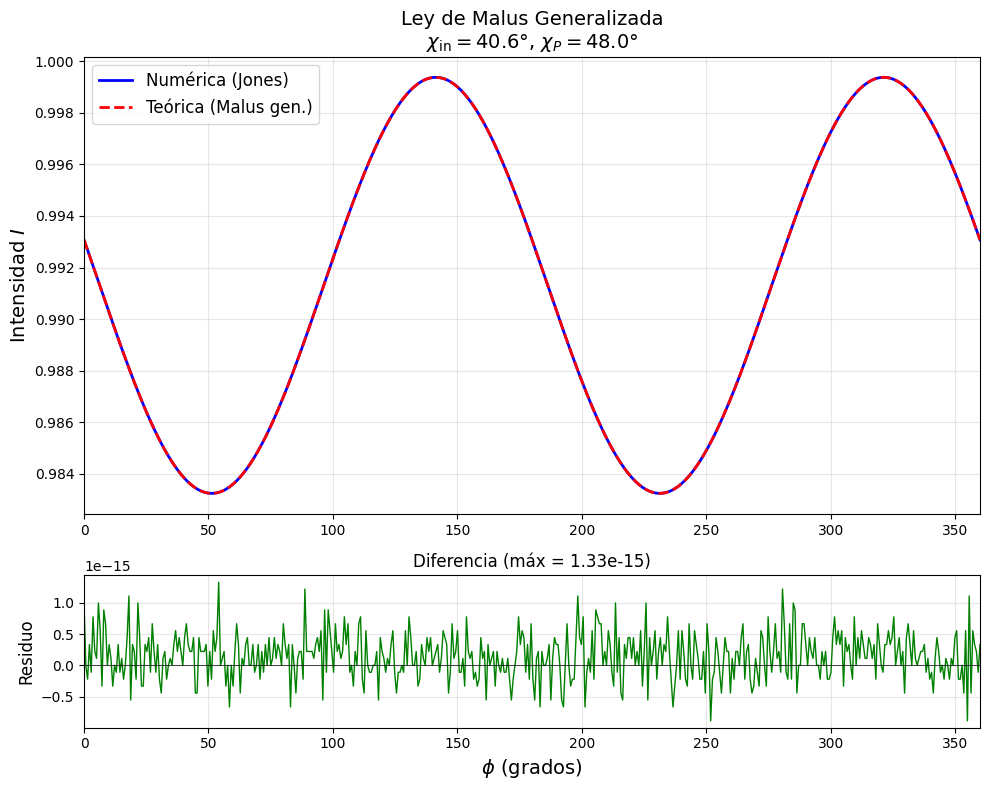


Error máximo absoluto: 1.33e-15
✓ La fórmula teórica reproduce exactamente el cálculo numérico.


In [16]:
# ============================================================
# Gráfica comparativa
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [3, 1]})

# --- Panel superior: Intensidades ---
ax1 = axes[0]
ax1.plot(np.degrees(phi_array), I_numerical, 'b-', linewidth=2, label='Numérica (Jones)')
ax1.plot(np.degrees(phi_array), I_theoretical, 'r--', linewidth=2, label='Teórica (Malus gen.)')
ax1.set_ylabel('Intensidad $I$', fontsize=14)
ax1.set_title(
    f'Ley de Malus Generalizada\n'
    f'$\\chi_{{\\rm in}}={np.degrees(chi_in_val):.1f}°$, '
    f'$\\chi_P={np.degrees(chi_P_val):.1f}°$',
    fontsize=14
)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 360)

# --- Panel inferior: Residuo ---
ax2 = axes[1]
residuo = I_numerical - I_theoretical
ax2.plot(np.degrees(phi_array), residuo, 'g-', linewidth=1)
ax2.set_xlabel('$\\phi$ (grados)', fontsize=14)
ax2.set_ylabel('Residuo', fontsize=12)
ax2.set_title(f'Diferencia (máx = {np.max(np.abs(residuo)):.2e})', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 360)
ax2.axhline(y=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig('malus_generalizada_verificacion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nError máximo absoluto: {np.max(np.abs(residuo)):.2e}")
print("✓ La fórmula teórica reproduce exactamente el cálculo numérico.")

---
## Paso 10: Visualización 3D — Superficie $I(\chi_P, \phi)$ para haz horizontal

Para el caso $\chi_{\text{in}} = 0$ (haz linealmente polarizado horizontal):

$$I = \frac{1}{2}\left[1 + \cos 2\chi_P \cos 2\phi\right]$$

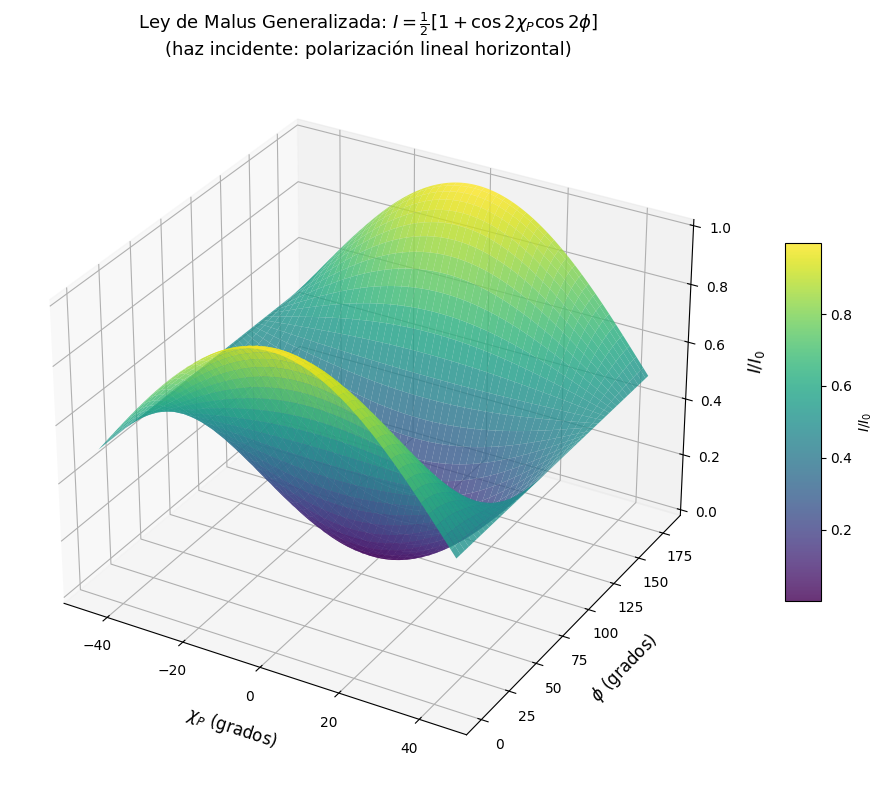

Observaciones:
  • En χ_P=0 (lineal): I oscila entre 0 y 1 → Malus clásica
  • En χ_P=±45° (circular): I = 1/2 constante
  • El 'piso' de intensidad sube con la elipticidad


In [17]:
# Superficie 3D para haz horizontal
chi_P_arr = np.linspace(-np.pi/4, np.pi/4, 200)
phi_arr = np.linspace(0, np.pi, 200)
CHI, PHI = np.meshgrid(chi_P_arr, phi_arr)

# Fórmula correcta
I_surface = 0.5 * (1 + np.cos(2*CHI) * np.cos(2*PHI))

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    np.degrees(CHI), np.degrees(PHI), I_surface,
    cmap='viridis', alpha=0.8, edgecolor='none'
)

ax.set_xlabel('$\\chi_P$ (grados)', fontsize=12, labelpad=10)
ax.set_ylabel('$\\phi$ (grados)', fontsize=12, labelpad=10)
ax.set_zlabel('$I / I_0$', fontsize=12, labelpad=10)
ax.set_title(
    'Ley de Malus Generalizada: $I = \\frac{1}{2}[1 + \\cos 2\\chi_P \\cos 2\\phi]$\n'
    '(haz incidente: polarización lineal horizontal)',
    fontsize=13
)

fig.colorbar(surf, shrink=0.5, aspect=10, label='$I/I_0$')
plt.tight_layout()
plt.savefig('malus_superficie_3D.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observaciones:")
print("  • En χ_P=0 (lineal): I oscila entre 0 y 1 → Malus clásica")
print("  • En χ_P=±45° (circular): I = 1/2 constante")
print("  • El 'piso' de intensidad sube con la elipticidad")

---
## Paso 11: Superficie general $I(\chi_{\text{in}}, \chi_P)$ a $\phi$ fijo

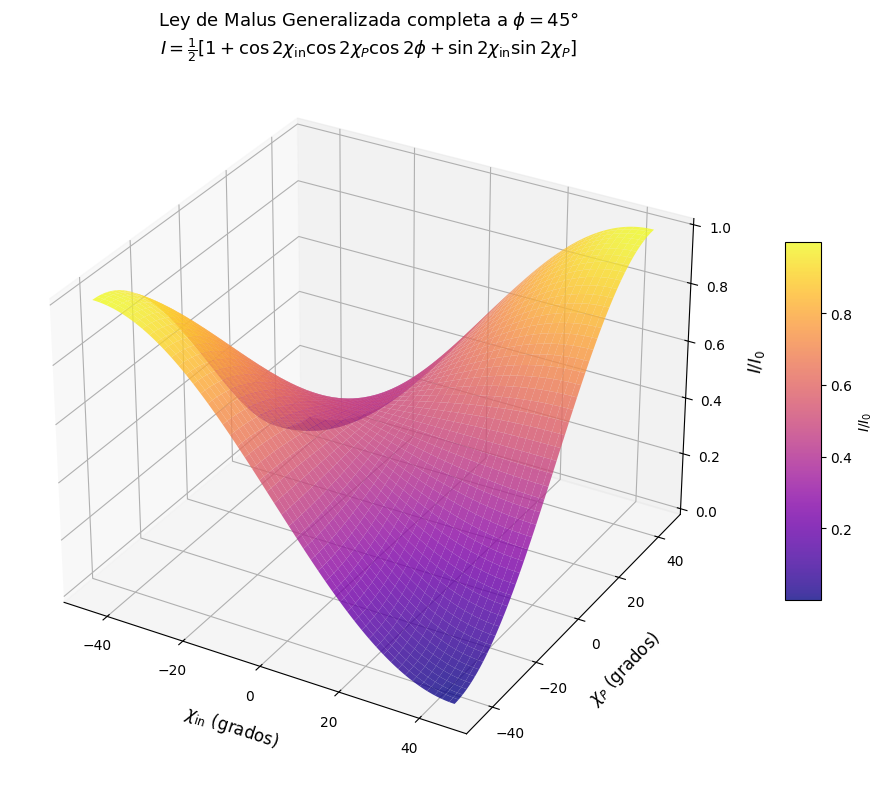

Observaciones:
  • La diagonal χ_in = χ_P muestra máxima transmisión
  • La antidiagonal χ_in = -χ_P muestra mínima transmisión
  • La dependencia en AMBAS elipticidades es manifiesta


In [18]:
# Superficie para phi fijo = pi/4
phi_fijo = np.pi / 4

chi_in_arr = np.linspace(-np.pi/4, np.pi/4, 200)
chi_P_arr = np.linspace(-np.pi/4, np.pi/4, 200)
CI, CP = np.meshgrid(chi_in_arr, chi_P_arr)

I_general = 0.5 * (
    1 
    + np.cos(2*CI) * np.cos(2*CP) * np.cos(2*phi_fijo) 
    + np.sin(2*CI) * np.sin(2*CP)
)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    np.degrees(CI), np.degrees(CP), I_general,
    cmap='plasma', alpha=0.8, edgecolor='none'
)

ax.set_xlabel('$\\chi_{\\rm in}$ (grados)', fontsize=12, labelpad=10)
ax.set_ylabel('$\\chi_P$ (grados)', fontsize=12, labelpad=10)
ax.set_zlabel('$I / I_0$', fontsize=12, labelpad=10)
ax.set_title(
    f'Ley de Malus Generalizada completa a $\\phi = {np.degrees(phi_fijo):.0f}°$\n'
    '$I = \\frac{1}{2}[1 + \\cos 2\\chi_{\\rm in}\\cos 2\\chi_P \\cos 2\\phi + \\sin 2\\chi_{\\rm in}\\sin 2\\chi_P]$',
    fontsize=13
)

fig.colorbar(surf, shrink=0.5, aspect=10, label='$I/I_0$')
plt.tight_layout()
plt.savefig('malus_general_chi_vs_chi.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observaciones:")
print("  • La diagonal χ_in = χ_P muestra máxima transmisión")
print("  • La antidiagonal χ_in = -χ_P muestra mínima transmisión")
print("  • La dependencia en AMBAS elipticidades es manifiesta")

---
## Resumen Final

### Ley de Malus Generalizada (forma de Poincaré):

$$\boxed{I = \frac{I_0}{2}\left[1 + \cos 2\chi_{\text{in}}\cos 2\chi_P \cos 2\phi + \sin 2\chi_{\text{in}}\sin 2\chi_P\right]}$$

### Forma del Haversine:

$$\boxed{I = I_0\left[1 - \sin^2(\chi_{\text{in}} - \chi_P) - \cos 2\chi_{\text{in}} \cos 2\chi_P \sin^2\phi\right]}$$

### Forma compacta (distancia en la esfera de Poincaré):

$$\boxed{I = I_0 \cos^2\frac{\Theta}{2}}$$

donde $\Theta$ es la distancia angular entre los vectores de Stokes del haz y del polarizador en la esfera de Poincaré.

### Casos particulares verificados:

| Caso | $\chi_{\text{in}}$ | $\chi_P$ | $\phi$ | $I$ |
|------|-----|------|------|-----|
| Malus clásica | $0$ | $0$ | $\phi$ | $I_0\cos^2\phi$ |
| Circular → lineal | $\pi/4$ | $0$ | cualquiera | $I_0/2$ |
| Alineados iguales | $\chi$ | $\chi$ | $0$ | $I_0$ |
| Cruzados iguales | $\chi$ | $\chi$ | $\pi/2$ | $I_0\sin^2 2\chi$ |
| Haz horizontal | $0$ | $\chi_P$ | $\phi$ | $\frac{I_0}{2}[1+\cos 2\chi_P\cos 2\phi]$ |